
KNN RESULTS
Accuracy: 0.8522167487684729
Confusion Matrix:
 [[  5   0   0   3   0]
 [  0 110   9   0   0]
 [  0   9  51   0   0]
 [  6   2   0   7   0]
 [  0   0   1   0   0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.62      0.53         8
           1       0.91      0.92      0.92       119
           2       0.84      0.85      0.84        60
           3       0.70      0.47      0.56        15
           4       0.00      0.00      0.00         1

    accuracy                           0.85       203
   macro avg       0.58      0.57      0.57       203
weighted avg       0.85      0.85      0.85       203


LOGISTIC REGRESSION RESULTS
Accuracy: 0.9605911330049262
Confusion Matrix:
 [[  5   1   0   2   0]
 [  0 118   1   0   0]
 [  0   1  59   0   0]
 [  0   2   0  13   0]
 [  0   0   1   0   0]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.62     

C:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

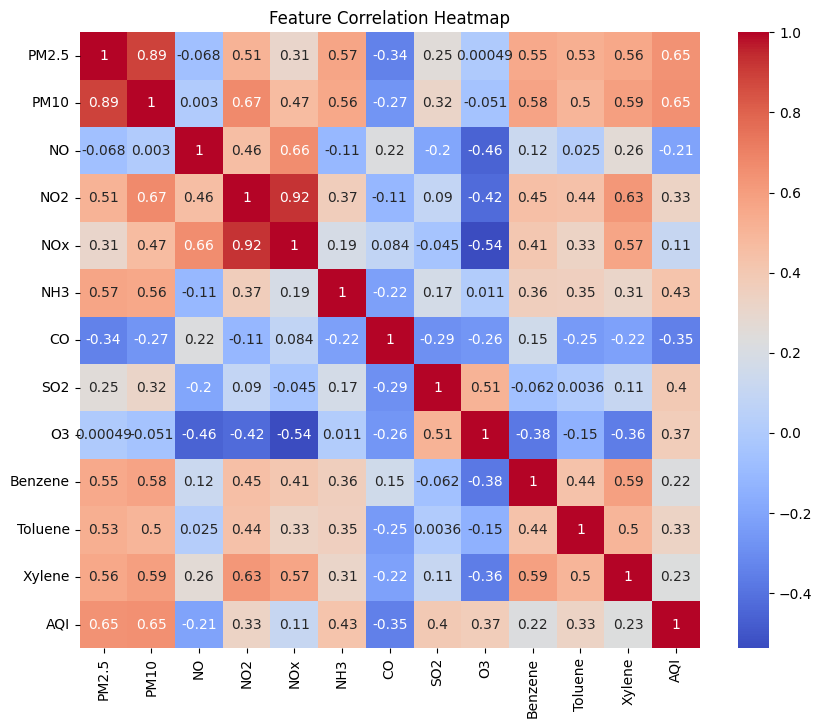

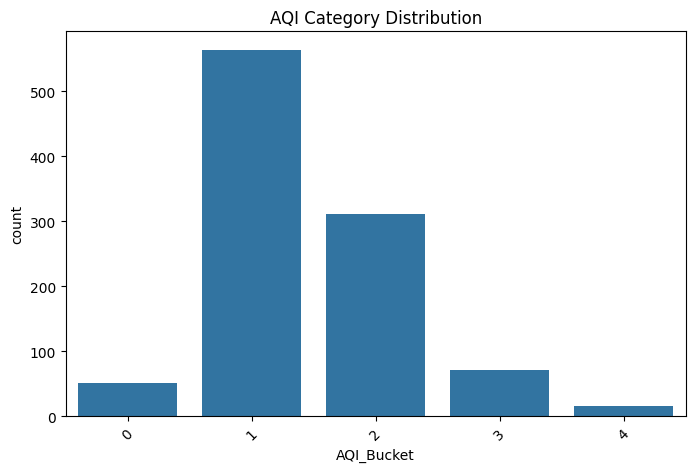

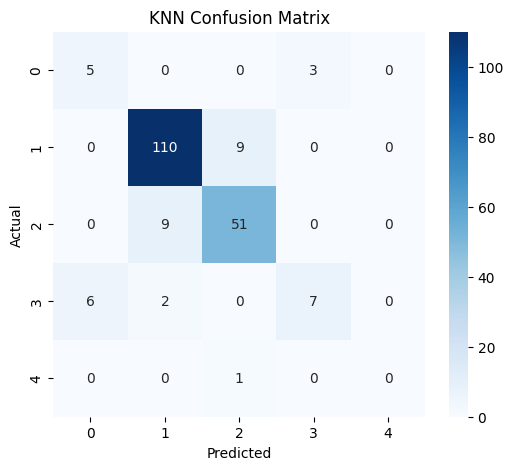

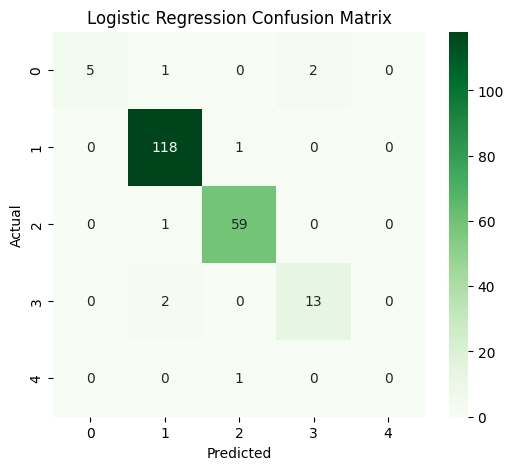

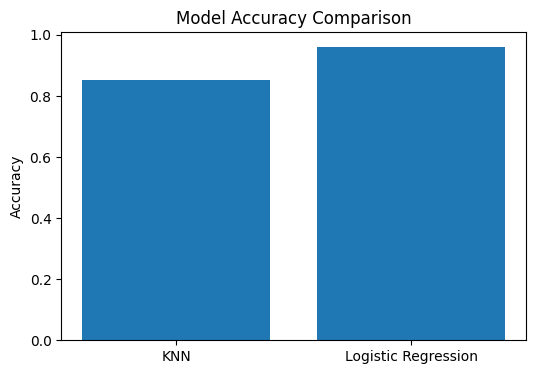

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


X = pd.read_csv('X_final.csv')
y = pd.read_csv('y_final.csv')

y = y['AQI_Bucket']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("\nKNN RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("\nLOGISTIC REGRESSION RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()



plt.figure(figsize=(8, 5))
sns.countplot(x=y)
plt.title("AQI Category Distribution")
plt.xticks(rotation=45)
plt.show()



cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

knn_acc = accuracy_score(y_test, y_pred_knn)
lr_acc = accuracy_score(y_test, y_pred_lr)

models = ['KNN', 'Logistic Regression']
accuracies = [knn_acc, lr_acc]

plt.figure(figsize=(6, 4))
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()
